
# Classification Twitter for Emotions

*italicized text*# Explain the code in the uploaded Jupyter notebook.

#  1. Loading Libraries and Dataset

The code likely begins by importing essential libraries such as:
pandas for data manipulation. numpy for numerical operations.
matplotlib or seaborn for data visualization.
NLP-specific libraries like sklearn or NLTK for text preprocessing and machine learning.
The dataset (presumably Twitter data) is loaded into a DataFrame, often using pandas.read_csv(). This dataset includes tweets and their corresponding emotion labels.

#  2. Exploratory Data Analysis (EDA)

Basic analysis of the dataset to understand its structure, such as:
Checking for null values or duplicates.
Displaying the distribution of emotion labels.
Visualizing the data using bar plots or histograms to understand class imbalances.

#  3. Text Preprocessing
The text data (tweets) undergoes cleaning and preprocessing:
Tokenization: Splitting text into individual words.
Lowercasing: Converting text to lowercase.
Stopword Removal: Removing common words like "and," "the," etc., that do not contribute to the meaning.
Stemming/Lemmatization: Reducing words to their root forms.
Removing Special Characters and URLs: Cleaning unwanted symbols and links.

#  4. Feature Extraction

Converting text into numerical representations:
Bag of Words (BoW): Represents text as a matrix of token counts.
TF-IDF (Term Frequency-Inverse Document Frequency): Weighs words based on their importance in the text.
Alternatively, word embeddings (e.g., Word2Vec, GloVe) may be used for richer semantic representation.

#  5. Model Building

Machine learning models like Logistic Regression, SVM, Naive Bayes, or deep learning models (e.g., LSTMs, Transformers) are trained on the dataset.
The workflow involves:
Splitting the data into training and testing sets.
Fitting the model to the training data.
Evaluating model performance on the testing set.

#  6. Model Evaluation

Metrics like accuracy, precision, recall, F1-score, or confusion matrix are used to assess model performance.
Visualization tools (e.g., ROC curve, precision-recall curve) might be used for deeper insights.

#  7. Optional: Hyperparameter Tuning

Optimizing model parameters using grid search or random search to improve performance.

#  8. Prediction and Visualization

Using the trained model to predict emotions for new or unseen tweets.
Visualizing the results, such as displaying the most common emotions or example tweets with predicted emotions.

# Dataset

# ![](https://i.gifer.com/7ARb.gif)

In [ ]:
import pandas as pd
import numpy as np
import panel as pn
import warnings; warnings.filterwarnings('ignore')

def show_panel(df):
    return pn.widgets.Tabulator(df.head(20),
                    show_index=False,
                    pagination='local',
                         page_size=10)


pn.extension('tabulator')
pn.widgets.Tabulator.theme = 'bootstrap'

validation = pd.read_csv('/kaggle/input/emotion-dataset/validation.csv')
train = pd.read_csv('/kaggle/input/emotion-dataset/training.csv')
test = pd.read_csv('/kaggle/input/emotion-dataset/test.csv')

print('Dataset information:')
print(f'Training data: {train.shape}')
print(f'Validation data: {validation.shape}')
print(f'Test data: {test.shape}')

Dataset information:
Training data: (16000, 2)
Validation data: (2000, 2)
Test data: (2000, 2)


In [ ]:
validation

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1
...,...,...
1995,im having ssa examination tomorrow in the morn...,0
1996,i constantly worry about their fight against n...,1
1997,i feel its important to share this info for th...,1
1998,i truly feel that if you are passionate enough...,1


In [ ]:
test

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0
...,...,...
1995,i just keep feeling like someone is being unki...,3
1996,im feeling a little cranky negative after this...,3
1997,i feel that i am useful to my people and that ...,1
1998,im feeling more comfortable with derby i feel ...,1


In [ ]:
train

,text,label,label_name,Words Per Tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             16000 non-null  object
 1   label            16000 non-null  int64 
 2   label_name       16000 non-null  object
 3   Words Per Tweet  16000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 500.1+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


In [ ]:
train.describe()

,label,Words Per Tweet
count,16000.000000,16000.000000
mean,1.565937,19.166313
std,1.501430,10.986905
min,0.000000,2.000000
25%,0.000000,11.000000
50%,1.000000,17.000000
75%,3.000000,25.000000
max,5.000000,66.000000


In [ ]:
show_panel(train)

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

### <b><span style='color:#F1A424'>Combine DataFrames into Dataset</span></b>
- It can be more intuitive to utilise **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">HuggingFace</mark>**'s Dataset  

In [ ]:
from datasets import Dataset,DatasetDict,Features,Value,ClassLabel

# Don't forget the class label data
class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
ft = Features({'text': Value('string'), 'label': ClassLabel(names=class_names)})

# Combine Multiple Datasets
emotions = DatasetDict({
    "train": Dataset.from_pandas(train,features=ft),
    "test": Dataset.from_pandas(test,features=ft),
    "validation": Dataset.from_pandas(validation,features=ft)
    })

# Convert a single DataFrame to a Dataset
# emotions = Dataset.from_pandas(train,features=ft)

emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

### <b><span style='color:#F1A424'>Selecting a Subset</span></b>
- We'll be working with the **training and validation dataset** in this problem
- Lets just show some useful fearures of the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Dataset</mark>** class

In [ ]:
# Training Data
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [ ]:
# Get First 5 Entries in Dictionary Format (Group them)
train_ds[:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

### <b><span style='color:#F1A424'>Dataset to DataFrame Convertion</span></b>
- Whenever we need a pandas `DataFrame`, eg. for visualisations, we can utlise the `Dataset`'' method `.set_format`

In [ ]:
# Convert Dataset to DataFrame (don't forget to reset)
emotions.set_format(type="pandas")
df = emotions["train"][:]
show_panel(df)

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

### <b><span style='color:#F1A424'>Adding Label Data</span></b>
- We made sure to not forget the `label_names` when converting from `DataFrame` to `Dataset`
- We can convert **numeric** values to **string** values by using method `int2str`

In [ ]:
# Add label data to dataframe
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
show_panel(df)

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>2 |</span></b> <b>CLASS DISTRIBUTION</b></div>

- Our dataset has 6 classes `joy`, `sadness`, `anger`, `fear`, `love` and `surprise`; multiclass problem

In [ ]:
import plotly.express as px
import pandas as pd

# Instead of using the undefined 'df', we use 'train'
import plotly.express as px
import pandas as pd

# Add the 'label_name' column to the 'train' DataFrame
train["label_name"] = train["label"].apply(label_int2str) # Using the same function you defined earlier

# Now you can use 'train' DataFrame with 'label_name' column
value_counts = train['label_name'].value_counts(ascending=True).reset_index()
value_counts.columns = ['Label Name', 'Count']

# ... (rest of your code remains the same)
# Create a bar chart with enhanced styling
fig = px.bar(value_counts,
             x='Count',
             y='Label Name',
             template='plotly_white',
             color='Count',  # Color by count for better distinction
             color_continuous_scale=px.colors.sequential.Viridis,  # Use a sequential color scale
             title='Counts of Each Label',  # Main title for the chart
             labels={'Count': 'Count of Instances', 'Label Name': 'Label'},  # Axis labels
             text='Count'  # Display count values on the bars
            )

# Update layout for better aesthetics
fig.update_traces(texttemplate='%{text}', textposition='outside')  # Position text outside
fig.update_layout(
    title_font=dict(size=24, color='black'),  # Customize title font size and color
    xaxis_title_font=dict(size=18, color='black'),  # Customize x-axis title font
    yaxis_title_font=dict(size=18, color='black'),  # Customize y-axis title font
    legend_title_font=dict(size=14),  # Customize legend title font
    legend=dict(x=1, y=1, traceorder='normal', orientation='h'),  # Customize legend position
    margin=dict(l=40, r=40, t=60, b=40)  # Adjust margins
)

# Show the figure
fig.show()

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>3 |</span></b> <b>LENGTH OF EACH TWEET</b></div>

- For applications using **DistilBERT**, the maximum context size is **512 tokens**
- Most tweets are around **10-20 words** long, which falls well within this limit

In [ ]:
import plotly.express as px
import pandas as pd
import pandas as pd
import plotly.express as px

# Use 'train' instead of 'df'
train["Words Per Tweet"] = train["text"].str.split().apply(len)

# Create the box plot with enhanced visuals
fig = px.box(
    train,  # Use 'train' here
    y='Words Per Tweet',
    color='label_name',
    title='Distribution of Words Per Tweet by Label',
    labels={
        'Words Per Tweet': 'Number of Words',
        'label_name': 'Label Name'
    },
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set2,  # Change color palette
)

# Customize layout
fig.update_layout(
    title_font=dict(size=24, color='darkblue'),
    yaxis_title_font=dict(size=16, color='dimgray'),
    xaxis_title_font=dict(size=16, color='dimgray'),
    legend_title_font=dict(size=16),
    boxmode='group'  # Side-by-side box plots
)

# Adding hover information for better understanding
fig.update_traces(
    boxmean='sd',  # Display mean and standard deviation in the hover info
    hovertemplate='Label: %{color}<br>Words Per Tweet: %{y}<br>Mean: %{mean:.2f}'
)

# Show the figure
fig.show()

<b>TOKENISATION</b></div>

### <b><span style='color:#F1A424'> 4.1 | </span>Character tokenisation </b>


In [ ]:
text = 'Tokenisation of text is a core task of NLP.'
tokenised_text = list(text)

# Character Tokenised list
print(f'Number of tokens: {len(tokenised_text)}')
print(tokenised_text)

Number of tokens: 43
['T', 'o', 'k', 'e', 'n', 'i', 's', 'a', 't', 'i', 'o', 'n', ' ', 'o', 'f', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


- Convert each character into an integer (numericalisation)
- `token2idx` gives us a mapping from each character in the **vocabulary** to a unique integer

In [ ]:
# Mapping Vecabulary dictionary
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenised_text)))}

print(f'Length of vocabulary: {len(token2idx)}')
print(token2idx)

Length of vocabulary: 18
{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'i': 10, 'k': 11, 'n': 12, 'o': 13, 'r': 14, 's': 15, 't': 16, 'x': 17}


### <b><span style='color:#F1A424'>Reconstructing text</span></b>
- Once we have a vocabulary dictionary, we can reconstruct the

In [ ]:
# Let's represent text in numerical format
input_ids = [token2idx[token] for token in tokenised_text]

print(f'{len(input_ids)} characters')
print(input_ids)

43 characters
[5, 13, 11, 8, 12, 10, 15, 6, 16, 10, 13, 12, 0, 13, 9, 0, 16, 8, 17, 16, 0, 10, 15, 0, 6, 0, 7, 13, 14, 8, 0, 16, 6, 15, 11, 0, 13, 9, 0, 3, 2, 4, 1]


### <b><span style='color:#F1A424'>Convert to OHE</span></b>

- Last step is to convert `input_ids` to a 2D tensor of one-hot vectors, let's use pytorch below
- One-Hot vectors are frequently used in ML applications to encode **categorical data** (either ordinal or nominal)
- For each of the 42 input token, we now have a one-hot vector with 18 dimensions (vocab size)

In [ ]:
import torch
import torch.nn.functional as F

inputs_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(inputs_ids,num_classes = len(token2idx))
print(f'OHE size: {one_hot_encodings.shape}')

OHE size: torch.Size([43, 18])


### <b><span style='color:#F1A424'>Drawbacks of Character Tokenisation</span></b>


### <b><span style='color:#F1A424'> 4.2 | </span>Word tokenisation </b>


In [ ]:
tokenised_text = text.split()
print(tokenised_text)

['Tokenisation', 'of', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


### <b><span style='color:#F1A424'> 4.3 | </span>Subword tokenisation </b>


In [ ]:
from transformers import AutoTokenizer

text = 'Tokenisation of text is a core task of NLP.'

# Load parameters of the tokeniser
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Show tokeniser information
tokenizer

# Or we can load the Tokeniser manually `transformers.DistilBertTokenizer`

# from transformers import DistilBertTokenizer

# model_ckpt = "distilbert-base-uncased"
# distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)
# distilbert_tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [ ]:
print('')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max length: {tokenizer.model_max_length}')
print(f'Tokeniser model input names: {tokenizer.model_input_names}')


Vocab size: 30522
Max length: 512
Tokeniser model input names: ['input_ids', 'attention_mask']


In [ ]:
print('Encoded text')
encoded_text = tokenizer(text)
print(encoded_text,'\n')

print('Tokens')
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens,'\n')

print('Convert tokens to string')
print(tokenizer.convert_tokens_to_string(tokens),'\n')

Encoded text
{'input_ids': [101, 19204, 6648, 1997, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]} 

Tokens
['[CLS]', 'token', '##isation', 'of', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]'] 

Convert tokens to string
[CLS] tokenisation of text is a core task of nlp. [SEP] 



In [ ]:
emotions.reset_format()

### <b><span style='color:#F1A424'> 4.4 | </span>Tokenising the entire dataset </b>


In [ ]:
# Tokenisation function
def tokenise(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

# Show the tokenised ids
ex_tokenised = tokenise(emotions["train"][:2])

In [ ]:
# Show attention mask
ex_tokenised['attention_mask']

[[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [ ]:
# apply to the entire dataset (train,test and validation dataset)
emotions_encoded = emotions.map(tokenise, batched=True, batch_size=None)
print(emotions_encoded["train"].column_names)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'attention_mask']


# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>5 |</span></b> <b>TRAINING A TEXT CLASSIFIER</b></div>


### <b><span style='color:#F1A424'> 5.1 | </span>Transformers as feature extractors </b>

### **<span style='color:#F1A424'>Using Pretrained Models</span>**


In [ ]:
import warnings; warnings.filterwarnings('ignore')
from transformers import AutoModel
import torch

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

### **<span style='color:#F1A424'>Extracting the last hidden state (example)</span>**


In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


- Depending on the model configuration, the model can contain several objects (**<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Hidden states</mark>**, **losses**, **attentions**, ...)
- The current model (`distilbert-base-uncased`) returns only one attribute, which is the `last_hidden_state`

In [ ]:
inputs = {k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)


In [ ]:
print(outputs.last_hidden_state.size())
print(outputs.last_hidden_state[:,0].size())

torch.Size([1, 6, 768])
torch.Size([1, 768])


### **<span style='color:#F1A424'>Extracting the last hidden state for the Dataset</span>**

- We know how to get the last hidden state for a single string, let's repeat the process for the entire dataset using `extract_hidden_states`

In [ ]:
def extract_hidden_states(batch):

    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state

    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [ ]:
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
# Extract last hidden states (faster w/ GPU)
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)
emotions_hidden["train"].column_names

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

### **<span style='color:#F1A424'>Creating the Feature Matrix</span>**


In [ ]:
X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
print(f'Training Dataset: {X_train.shape}')
print(f'Validation Dataset {X_valid.shape}')

Training Dataset: (16000, 768)
Validation Dataset (2000, 768)


In [ ]:
# Let's check our dataset
X_train

array([[-0.1167513 ,  0.09857138, -0.12962897, ...,  0.0587108 ,
         0.35432693,  0.4042067 ],
       [-0.03236292, -0.03231524, -0.19572599, ..., -0.17465737,
         0.35463768,  0.30276582],
       [ 0.03974647,  0.2022336 ,  0.14227113, ..., -0.11406833,
         0.33937776,  0.395831  ],
       ...,
       [-0.00339847, -0.09585506,  0.05843544, ..., -0.04272703,
         0.2495916 ,  0.30761623],
       [ 0.06660261,  0.17334324,  0.12896673, ...,  0.06118569,
         0.29038215,  0.46844164],
       [ 0.01668789,  0.10127088, -0.00731721, ..., -0.06493651,
         0.34540522,  0.21993564]], dtype=float32)

### **<span style='color:#F1A424'>Visualising the Training Data</span>**



In [ ]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

# Scale the data
X_scaled = MinMaxScaler().fit_transform(X_train)

# lower dimension transformation
model = TSNE(n_components=2).fit(X_scaled)

# Create a df of 2D embeddings
df_embedding = pd.DataFrame(model.embedding_, columns=["X", "Y"])
df_embedding["label"] = y_train

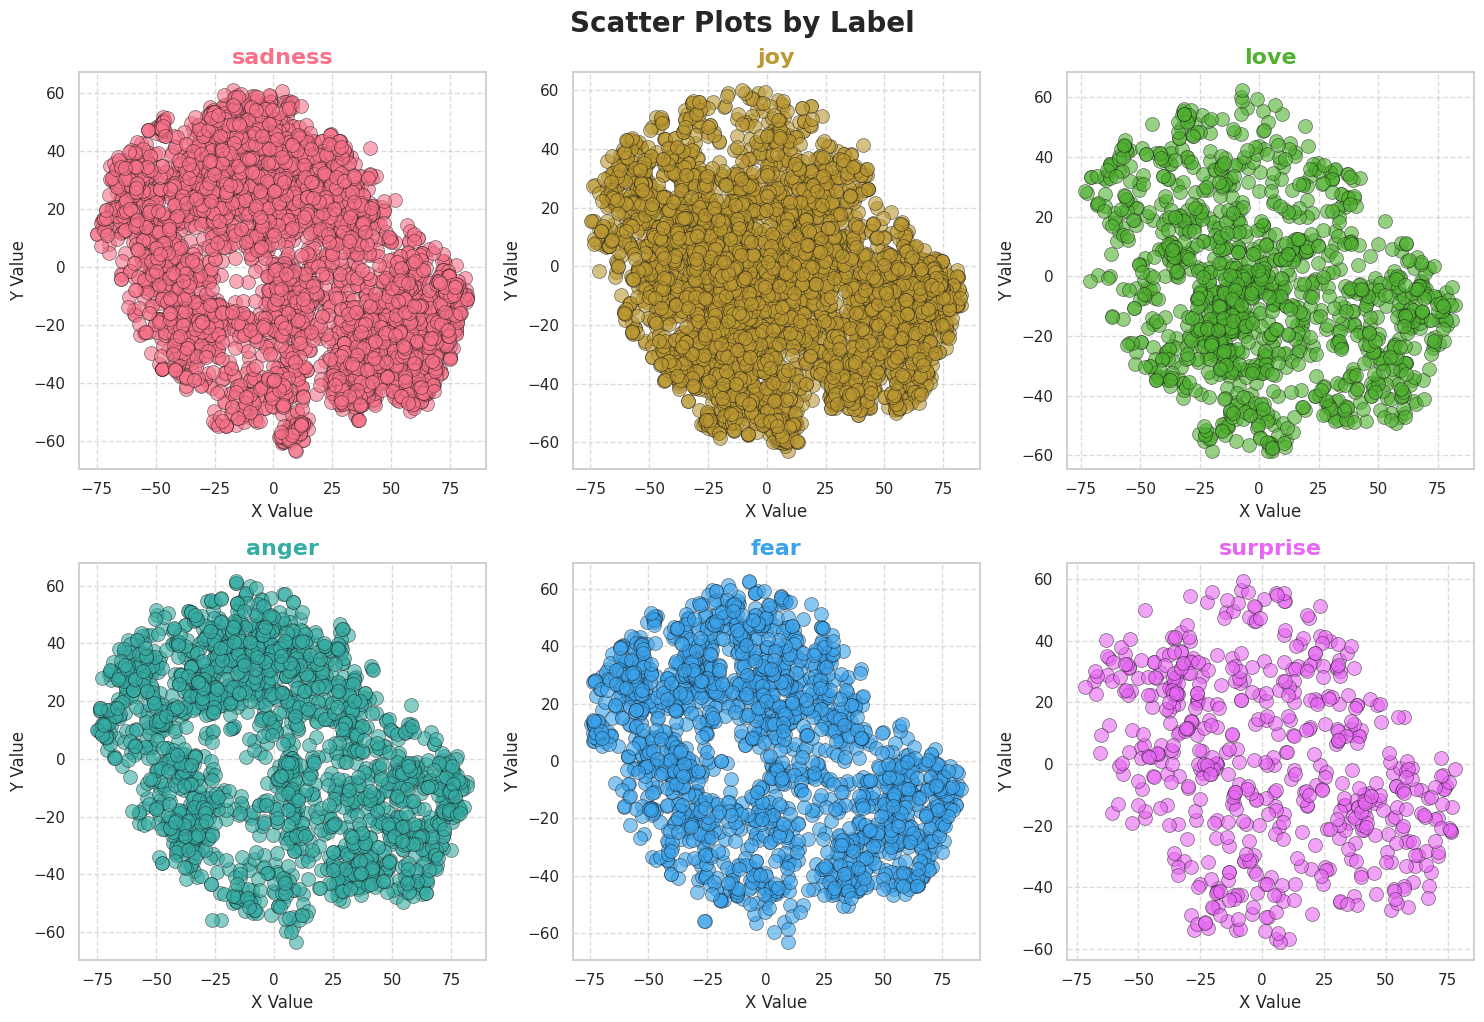

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for seaborn
sns.set(style='whitegrid')

# Create a colormap with distinct colors for each label
num_labels = len(emotions["train"].features["label"].names)
colors = sns.color_palette("husl", num_labels)  # Use a distinct color palette

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
labels = emotions["train"].features["label"].names

# Scatter plot for each label
for i, label in enumerate(labels):
    dict_embedding_sub = dict(tuple(df_embedding.groupby('label')))
    df_embedding_sub = dict_embedding_sub[i]

    # Scatter plot with distinct colors and sizes
    scatter = axes[i].scatter(
        df_embedding_sub["X"],
        df_embedding_sub["Y"],
        lw=0.5,
        ec='k',
        alpha=0.6,
        color=colors[i],
        s=100  # Adjust marker size
    )

    # Set title with enhanced aesthetics
    axes[i].set_title(f'{label}', fontsize=16, fontweight='bold', color=colors[i])

    # Add grid for improved readability
    axes[i].grid(True, linestyle='--', alpha=0.7)

    # Set labels for the axes
    axes[i].set_xlabel('X Value', fontsize=12)
    axes[i].set_ylabel('Y Value', fontsize=12)

# Adjust tight layout for better spacing
plt.tight_layout()
plt.suptitle('Scatter Plots by Label', fontsize=20, fontweight='bold', y=1.02)  # main title
plt.show()

From this plot we can see some clear patterns:
- For **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">positive emotions</mark>** (**<span style='color:#FFC300'>joy</span>** and **<span style='color:#FFC300'>love</span>**) are well separated from the **<span style='color:#FFC300'>negative emotions</span>** and also share a similar space
- **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Negative emotions</mark>** (**<span style='color:#FFC300'>sadness</span>**, **<span style='color:#FFC300'>anger</span>**, and **<span style='color:#FFC300'>fear</span>**) all occupy very similar regions with slightly varying distributions in **<span style='color:#FFC300'>lower dimension space</span>**
- Finally, **<span style='color:#FFC300'>surprise</span>** is somewhat scattered all over the **<span style='color:#FFC300'>lower dimension space</span>**

### **<span style='color:#F1A424'>Training a Baseline Model</span>**


In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
print(f'accuracy: {dummy_clf.score(X_valid, y_valid)}')

accuracy: 0.352


In [ ]:
from sklearn.linear_model import LogisticRegression as LR

# We increase `max_iter` to guarantee convergence
lr_clf = LR(max_iter = 2000)
lr_clf.fit(X_train, y_train)
y_preds = lr_clf.predict(X_valid)
print(f'accuracy: {lr_clf.score(X_valid, y_valid)}')

accuracy: 0.634


### <b><span style='color:#F1A424'>Confusion Matrix</span></b>

- Our **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">logistic regression</mark>** model with `DistilBERT` **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">embeddings</mark>** is signifcantly better than the baseline `DummyClassifier`
- Let check the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">confusion matrix</mark>** of the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">logistic regression</mark>** model

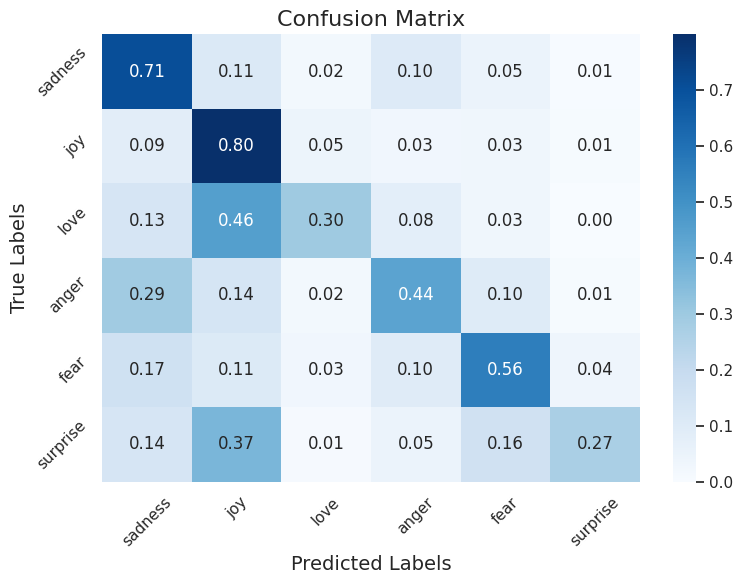

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_model, y_true, labels):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_model, normalize='true')

    # Create a heatmap using seaborn for better aesthetics
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=True)

    # Add titles and labels
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
plot_confusion_matrix(y_preds, y_valid, labels)

From the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">confusion matrix</mark>** we can say that:

- **<span style='color:#FFC300'>anger</span>**, **<span style='color:#FFC300'>fear</span>** & **<span style='color:#FFC300'>surprise</span>** often confused with **<span style='color:#FFC300'>sadness</span>** (0.29, 0.17 & 0.14) (observation we made when visualising the embeddings)
- **<span style='color:#FFC300'>love</span>** & **<span style='color:#FFC300'>surprise</span>** are frequently mistaken for **<span style='color:#FFC300'>joy</span>** (0.37 & 0.46)

### <b><span style='color:#F1A424'> 5.2 | </span>Fine-tuning transformers </b>

### <b><span style='color:#F1A424'>Loading a Pretrained Model</span></b>



In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = 6

model_ckpt = "distilbert-base-uncased"
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt,
                          num_labels=num_labels)
         .to(device))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### <b><span style='color:#F1A424'>Defining the Performance Metrics</span></b>
- We'll monitor the `F1 score`  & `accuracy`, the function is required to be passed in the `Trainer` class



In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

### <b><span style='color:#F1A424'>Training parameters</span></b>
-

In [ ]:
from transformers import Trainer, TrainingArguments

bs = 64 # batch size
logging_steps = len(emotions_encoded["train"]) // bs
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=3,             # number of training epochs
                                  learning_rate=2e-5,             # model learning rate
                                  per_device_train_batch_size=bs, # batch size
                                  per_device_eval_batch_size=bs,  # batch size
                                  weight_decay=0.01,
                                  evaluation_strategy="epoch",
                                  disable_tqdm=False,
                                  report_to="none",
                                  logging_steps=logging_steps,
                                  push_to_hub=False,
                                  log_level="error")

### <b><span style='color:#F1A424'>Train Model</span></b>
- With the training arguments set, we need to define the `Trainer` and start training with the `train()` method

In [ ]:
import os
from transformers import Trainer
os.environ['WANDB_DISABLED'] = 'true'

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  tokenizer=tokenizer)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.828100,0.290444,0.916500,0.916810
2,0.222300,0.182666,0.933500,0.933795
3,0.149200,0.171792,0.933000,0.933055


TrainOutput(global_step=750, training_loss=0.3998650817871094, metrics={'train_runtime': 204.2025, 'train_samples_per_second': 235.061, 'train_steps_per_second': 3.673, 'total_flos': 1080514292544000.0, 'train_loss': 0.3998650817871094, 'epoch': 3.0})

In [ ]:
# Predict on Validation Dataset
pred_output = trainer.predict(emotions_encoded["validation"])
pred_output

PredictionOutput(predictions=array([[ 5.2247324 , -0.64512515, -0.9497445 , -0.80603135, -1.1323823 ,
        -1.683731  ],
       [ 5.2382197 , -0.7161323 , -1.3737128 , -0.6989539 , -0.5652353 ,
        -1.6738945 ],
       [-1.2012106 ,  2.4449208 ,  3.132622  , -1.4191277 , -1.9252961 ,
        -1.5525618 ],
       ...,
       [-0.8418323 ,  5.14028   , -0.2257137 , -1.2705227 , -1.8643713 ,
        -1.3651775 ],
       [-1.5369034 ,  2.8882513 ,  2.9410665 , -1.4094367 , -1.8965334 ,
        -1.3317761 ],
       [-1.0856816 ,  5.0136123 , -0.4213179 , -1.5916066 , -1.7560803 ,
        -0.56352186]], dtype=float32), label_ids=array([0, 0, 2, ..., 1, 1, 1]), metrics={'test_loss': 0.17179159820079803, 'test_accuracy': 0.933, 'test_f1': 0.9330552004021757, 'test_runtime': 2.2599, 'test_samples_per_second': 884.985, 'test_steps_per_second': 14.16})

In [ ]:
print(f'Output Predition: {pred_output.predictions.shape}')
print(pred_output.predictions)

Output Predition: (2000, 6)
[[ 5.2247324  -0.64512515 -0.9497445  -0.80603135 -1.1323823  -1.683731  ]
 [ 5.2382197  -0.7161323  -1.3737128  -0.6989539  -0.5652353  -1.6738945 ]
 [-1.2012106   2.4449208   3.132622   -1.4191277  -1.9252961  -1.5525618 ]
 ...
 [-0.8418323   5.14028    -0.2257137  -1.2705227  -1.8643713  -1.3651775 ]
 [-1.5369034   2.8882513   2.9410665  -1.4094367  -1.8965334  -1.3317761 ]
 [-1.0856816   5.0136123  -0.4213179  -1.5916066  -1.7560803  -0.56352186]]


In [ ]:
# Decode the predictions greedily using argmax (highest value of all classes)
y_preds = np.argmax(pred_output.predictions,axis=1)
print(f'Output Prediction:{y_preds.shape}')
print(f'Predictions: {y_preds}')

Output Prediction:(2000,)
Predictions: [0 0 2 ... 1 2 1]


In [ ]:
# Show metrics of last iteration
pred_output.metrics

{'test_loss': 0.17179159820079803,
 'test_accuracy': 0.933,
 'test_f1': 0.9330552004021757,
 'test_runtime': 2.2599,
 'test_samples_per_second': 884.985,
 'test_steps_per_second': 14.16}

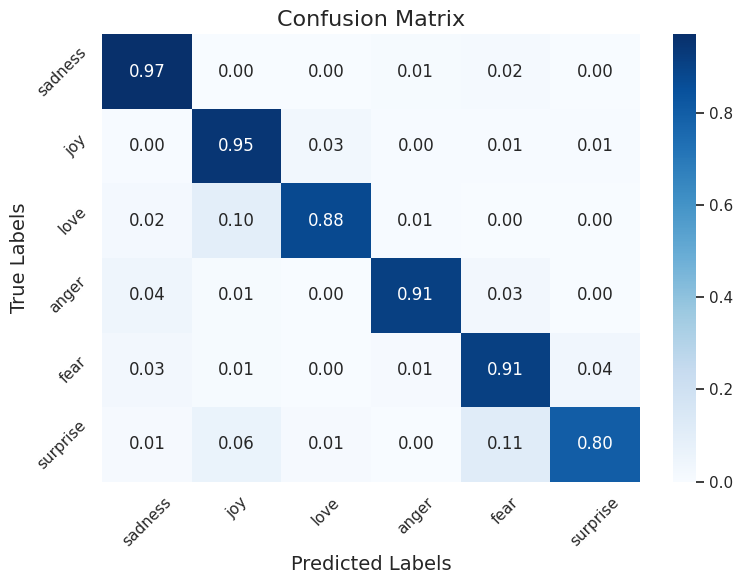

In [ ]:
plot_confusion_matrix(y_preds,y_valid,labels)

From the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">confusion matrix</mark>** we can say that:
- The **fine-tune** approach (using **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>**)  performs much better than simple extracting **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">embedding</mark>** data and training it on a separate ML model
- **<span style='color:#FFC300'>love</span>** is still often confused with **<span style='color:#FFC300'>joy</span>** (0.08), but much less than the first approach
- **<span style='color:#FFC300'>surprise</span>** is often confused with **<span style='color:#FFC300'>joy</span>** as well (0.09) or fear (0.10), both also much less than the first approach

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>6 |</span></b> <b>MODEL ERROR ANALYSIS</b></div>

### <b><span style='color:#F1A424'>Loss Value Mapping</span></b>

We should investigate our models' prediction a little more
- A simple, yet powerful technique is to sort the validateion by the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">model loss</mark>**
- We can write a function that returns the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">model loss</mark>**, together with the predicted label `forward_pass_with_label`

In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):

    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(forward_pass_with_label,
                                                                    batched=True,
                                                                    batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

### <b><span style='color:#F1A424'>Convert to DataFrame</span></b>

- Create a DataFrame with the text, losses, predicted/true labels

In [ ]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"].apply(label_int2str))

- Now we can sort `emotions` encoded by the losses in either assending/descending order
- Let's look at the data samples with the **highest losses** (we can see that high loss values are associated with misspredictions)

In [ ]:
show_panel(df_test.sort_values("loss", ascending=False))

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

In [ ]:
show_panel(df_test.sort_values("loss", ascending=True))

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>7 |</span></b> <b>USING OUR MODEL</b></div>

- We have trained the model utilising `AutoModelForSequenceClassification` which added a classification head to the base **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>** model
- We can utilise the `pipeline` method when we need to make model predictions on new unseed data
- Let's say we have new unseen data:
    - 'I watched a movie last night, it was quite brilliant'

In [ ]:
# Save the model
trainer.save_model()

In [ ]:
from transformers import pipeline

# load from previously saved model
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-emotion")

# New unseen by model data
new_data = 'I have watched a movie which was quite awesome book'

- Our model predicts `new_data` to be classified to **label 1** (**joy**)

In [ ]:
preds = classifier(new_data, return_all_scores=True)
preds

[[{'label': 'LABEL_0', 'score': 0.0034895832650363445},
  {'label': 'LABEL_1', 'score': 0.9853148460388184},
  {'label': 'LABEL_2', 'score': 0.00334287341684103},
  {'label': 'LABEL_3', 'score': 0.0027378571685403585},
  {'label': 'LABEL_4', 'score': 0.001269674627110362},
  {'label': 'LABEL_5', 'score': 0.0038451107684522867}]]

In [ ]:
preds[0]

[{'label': 'LABEL_0', 'score': 0.0034895832650363445},
 {'label': 'LABEL_1', 'score': 0.9853148460388184},
 {'label': 'LABEL_2', 'score': 0.00334287341684103},
 {'label': 'LABEL_3', 'score': 0.0027378571685403585},
 {'label': 'LABEL_4', 'score': 0.001269674627110362},
 {'label': 'LABEL_5', 'score': 0.0038451107684522867}]